<a href="https://colab.research.google.com/github/MBR4V0/Python/blob/main/Regressao_completa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ DADOS ================

   Horas_Estudo  Projetos  Experiencia  Salario
0             1         1            0     2202
1             2         1            1     3935
2             3         2            1     5460
3             4         2            2     6270
4             5         3            2     7206
5             6         3            3     8571
6             7         4            3    10300
7             8         4            4    11020
8             9         5            4    12714
9            10         5            5    13621

REGRESSÃO LINEAR SIMPLES

Intercepto: 1280.60
Coeficiente: 1245.33

R²: 0.9949
MAE: 228.56
RMSE: 256.28
Correlação de Pearson: 0.9974
P-valor: 0.000000

REGRESSÃO LINEAR MÚLTIPLA

Intercepto: 1185.50

Coeficientes:
Horas_Estudo: 833.10
Projetos: 559.20
Experiencia: 273.90

R²: 0.9953
MAE: 216.46
RMSE: 246.47

REGRESSÃO NÃO LINEAR

Intercepto: 1192.10

Coeficientes Polinomiais:
Coeficiente 0: 0.00
Coeficiente 1: 1289.58
Coefic

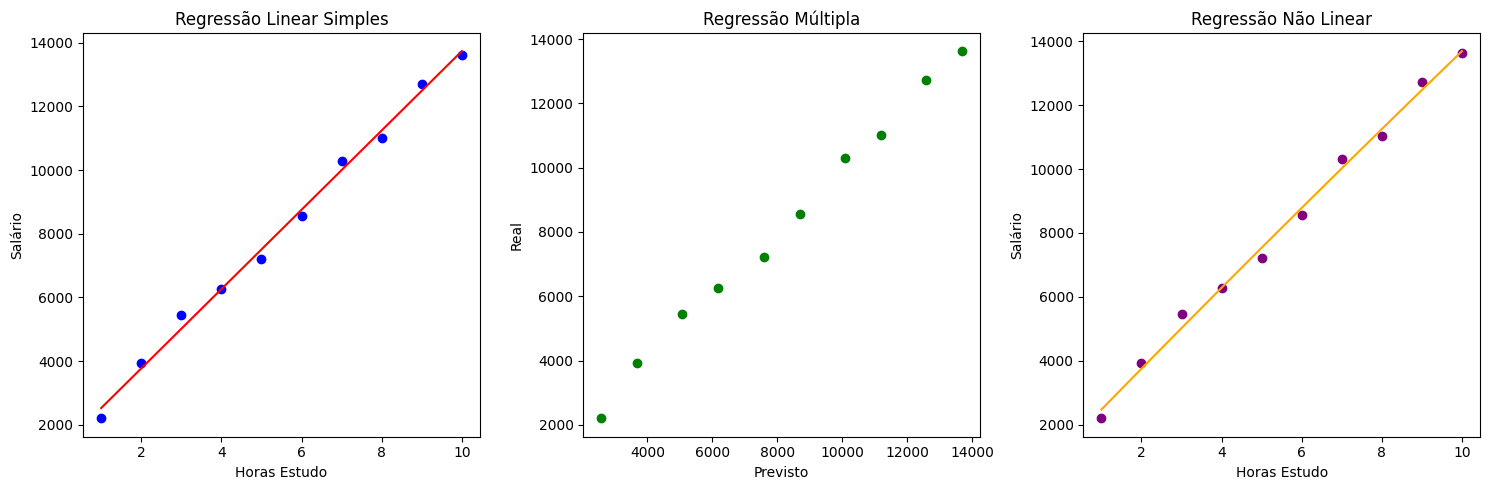


COMPARAÇÃO DOS MODELOS

            Modelo        R²         MAE        RMSE
0   Linear Simples  0.994893  228.563636  256.281401
1  Linear Múltipla  0.995276  216.460000  246.469187
2       Não Linear  0.994959  226.945455  254.608973

MELHOR MODELO

Modelo    Linear Múltipla
R²               0.995276
MAE                216.46
RMSE           246.469187
Name: 1, dtype: object

Programa finalizado com sucesso.


In [1]:
# ============================================================
# REGRESSÃO COMPLETA EM PYTHON
# ------------------------------------------------------------
# Este programa faz:
#
# 1. Regressão Linear Simples
# 2. Regressão Linear Múltipla
# 3. Regressão Não Linear (Polinomial)
# 4. Inferência Estatística
#    - R²
#    - MAE
#    - RMSE
#    - Correlação
#
# Bibliotecas necessárias:
# pip install numpy pandas matplotlib scikit-learn scipy
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from scipy.stats import pearsonr

# ============================================================
# GERANDO DADOS
# ============================================================

np.random.seed(42)

# Variáveis independentes
horas_estudo = np.array([1,2,3,4,5,6,7,8,9,10])

projetos = np.array([1,1,2,2,3,3,4,4,5,5])

experiencia = np.array([0,1,1,2,2,3,3,4,4,5])

# Variável dependente
# Simulando dados mais próximos da realidade
salario = (
    1500
    + horas_estudo * 400
    + projetos * 700
    + experiencia * 1000
    + np.random.randint(-500, 500, 10)
)

# ============================================================
# DATAFRAME
# ============================================================

dados = pd.DataFrame({
    "Horas_Estudo": horas_estudo,
    "Projetos": projetos,
    "Experiencia": experiencia,
    "Salario": salario
})

print("\n================ DADOS ================\n")
print(dados)

# ============================================================
# 1. REGRESSÃO LINEAR SIMPLES
# ============================================================

print("\n=======================================")
print("REGRESSÃO LINEAR SIMPLES")
print("=======================================\n")

X_simples = dados[["Horas_Estudo"]]
y = dados["Salario"]

modelo_simples = LinearRegression()

modelo_simples.fit(X_simples, y)

pred_simples = modelo_simples.predict(X_simples)

# Métricas
r2_simples = r2_score(y, pred_simples)
mae_simples = mean_absolute_error(y, pred_simples)
rmse_simples = np.sqrt(mean_squared_error(y, pred_simples))

print(f"Intercepto: {modelo_simples.intercept_:.2f}")
print(f"Coeficiente: {modelo_simples.coef_[0]:.2f}")

print(f"\nR²: {r2_simples:.4f}")
print(f"MAE: {mae_simples:.2f}")
print(f"RMSE: {rmse_simples:.2f}")

# Correlação
corr, pvalor = pearsonr(
    dados["Horas_Estudo"],
    dados["Salario"]
)

print(f"Correlação de Pearson: {corr:.4f}")
print(f"P-valor: {pvalor:.6f}")

# ============================================================
# 2. REGRESSÃO LINEAR MÚLTIPLA
# ============================================================

print("\n=======================================")
print("REGRESSÃO LINEAR MÚLTIPLA")
print("=======================================\n")

X_multipla = dados[
    ["Horas_Estudo", "Projetos", "Experiencia"]
]

modelo_multipla = LinearRegression()

modelo_multipla.fit(X_multipla, y)

pred_multipla = modelo_multipla.predict(X_multipla)

# Métricas
r2_multipla = r2_score(y, pred_multipla)
mae_multipla = mean_absolute_error(y, pred_multipla)
rmse_multipla = np.sqrt(
    mean_squared_error(y, pred_multipla)
)

print(f"Intercepto: {modelo_multipla.intercept_:.2f}")

print("\nCoeficientes:")

for nome, coef in zip(
    X_multipla.columns,
    modelo_multipla.coef_
):
    print(f"{nome}: {coef:.2f}")

print(f"\nR²: {r2_multipla:.4f}")
print(f"MAE: {mae_multipla:.2f}")
print(f"RMSE: {rmse_multipla:.2f}")

# ============================================================
# 3. REGRESSÃO NÃO LINEAR (POLINOMIAL)
# ============================================================

print("\n=======================================")
print("REGRESSÃO NÃO LINEAR")
print("=======================================\n")

# Vamos usar Horas_Estudo como variável

X_poly = dados[["Horas_Estudo"]]

poly = PolynomialFeatures(degree=2)

X_poly_transformado = poly.fit_transform(X_poly)

modelo_poly = LinearRegression()

modelo_poly.fit(X_poly_transformado, y)

pred_poly = modelo_poly.predict(
    X_poly_transformado
)

# Métricas
r2_poly = r2_score(y, pred_poly)
mae_poly = mean_absolute_error(y, pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y, pred_poly))

print(f"Intercepto: {modelo_poly.intercept_:.2f}")

print("\nCoeficientes Polinomiais:")

for i, coef in enumerate(modelo_poly.coef_):
    print(f"Coeficiente {i}: {coef:.2f}")

print(f"\nR²: {r2_poly:.4f}")
print(f"MAE: {mae_poly:.2f}")
print(f"RMSE: {rmse_poly:.2f}")

# ============================================================
# PREVISÃO FINAL
# ============================================================

print("\n=======================================")
print("PREVISÕES")
print("=======================================\n")

novo_dado = pd.DataFrame({
    "Horas_Estudo": [7],
    "Projetos": [4],
    "Experiencia": [3]
})

# Simples
pred1 = modelo_simples.predict(
    novo_dado[["Horas_Estudo"]]
)

# Múltipla
pred2 = modelo_multipla.predict(
    novo_dado
)

# Não linear
novo_poly = poly.transform(
    novo_dado[["Horas_Estudo"]]
)

pred3 = modelo_poly.predict(novo_poly)

print(f"Regressão Simples: R$ {pred1[0]:.2f}")

print(f"Regressão Múltipla: R$ {pred2[0]:.2f}")

print(f"Regressão Não Linear: R$ {pred3[0]:.2f}")

# Média das previsões
media_final = (pred1[0] + pred2[0] + pred3[0]) / 3

print(f"\nMédia Final das Previsões: R$ {media_final:.2f}")

# ============================================================
# VISUALIZAÇÕES
# ============================================================

plt.figure(figsize=(15,5))

# ------------------------------------------------
# REGRESSÃO SIMPLES
# ------------------------------------------------

plt.subplot(1,3,1)

plt.scatter(
    dados["Horas_Estudo"],
    y,
    color='blue'
)

plt.plot(
    dados["Horas_Estudo"],
    pred_simples,
    color='red'
)

plt.title("Regressão Linear Simples")

plt.xlabel("Horas Estudo")
plt.ylabel("Salário")

# ------------------------------------------------
# REGRESSÃO MÚLTIPLA
# ------------------------------------------------

plt.subplot(1,3,2)

plt.scatter(
    pred_multipla,
    y,
    color='green'
)

plt.title("Regressão Múltipla")

plt.xlabel("Previsto")
plt.ylabel("Real")

# ------------------------------------------------
# REGRESSÃO NÃO LINEAR
# ------------------------------------------------

plt.subplot(1,3,3)

plt.scatter(
    dados["Horas_Estudo"],
    y,
    color='purple'
)

# Ordenando para desenhar curva
ordem = np.argsort(
    dados["Horas_Estudo"]
)

plt.plot(
    dados["Horas_Estudo"].values[ordem],
    pred_poly[ordem],
    color='orange'
)

plt.title("Regressão Não Linear")

plt.xlabel("Horas Estudo")
plt.ylabel("Salário")

plt.tight_layout()

plt.show()

# ============================================================
# COMPARAÇÃO FINAL DOS MODELOS
# ============================================================

print("\n=======================================")
print("COMPARAÇÃO DOS MODELOS")
print("=======================================\n")

comparacao = pd.DataFrame({
    "Modelo": [
        "Linear Simples",
        "Linear Múltipla",
        "Não Linear"
    ],
    "R²": [
        r2_simples,
        r2_multipla,
        r2_poly
    ],
    "MAE": [
        mae_simples,
        mae_multipla,
        mae_poly
    ],
    "RMSE": [
        rmse_simples,
        rmse_multipla,
        rmse_poly
    ]
})

print(comparacao)

# ============================================================
# MELHOR MODELO
# ============================================================

melhor = comparacao.loc[
    comparacao["R²"].idxmax()
]

print("\n=======================================")
print("MELHOR MODELO")
print("=======================================\n")

print(melhor)

print("\nPrograma finalizado com sucesso.")